## Libraries and Data.


In [1]:
import pandas as pd
import numpy as np
import string
import regex as re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords 
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import StandardScaler
from gensim.models import Word2Vec
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

# Download NLTK data. Needs to be runned once per session. Can be commented after.
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /home/siavashj/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/siavashj/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/siavashj/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
# Loading the data.

df_orig = pd.read_parquet('FNDDSeverything.parquet.gzip')
df = df_orig.select_dtypes(include="str")


## PIECE 1: Data Cleaning and Vectorizing


In [3]:
# print(re.sub(r',', ' ', "BACN,CAND,FL,4PC, Z"))

In [4]:
# df = df.dropna(subset=['description'])  # Remove nulls
# # df['description'] = df['description'].str.lower()  # lowercase

# ## Remove special characters.

# translator = str.maketrans('', '', string.punctuation)
# description_clean =[]
# for index, text in enumerate(df.description):
#     clean = text.translate(translator)
#     description_clean.append(clean)

# df['description_clean'] = description_clean

# df['description_clean'] =df['description_clean'].str.strip()  # remove whitespace

def preprocess_food_entries(text, Tokenize = True):
    """
    Complete preprocessing for food descriptions
    - Removes measurements and numbers
    - Tokenizes
    - Removes stopwords
    - Lemmatizes
    """
    sentence = ''

    # Step 1: Lowercase
    text = text.lower()

    # Step 0: replace ',' with ' '.
    text = re.sub(r',|/', ' ', text)
    

    # Step 3: Clean special characters but keep spaces
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Step 2: Remove all measurement patterns
    patterns_to_remove = [
        r'\d+\.?\d*\s?(?:oz|lb|lbs|g|kg|ml|l|cup|cups|tsp|tbsp|pt|qt|gal|mg|mcg|cal|count|ct|pack|pk|piece|pieces|pc|ounce|ounces|pound|pounds|gram|grams|kilogram|kilograms|milliliter|milliliters|liter|liters|teaspoon|teaspoons|tablespoon|tablespoons|pint|pints|quart|quarts|gallon|gallons|milligram|milligrams|microgram|micrograms|calorie|calories|fl|fluid)\b',
        r'\b\d+\.?\d*\b',  # standalone numbers
        r'\d+\.?\d*\s?%',  # percentages
        r'\d+\s?x\s?\d+',  # dimensions
    ]
    
    for pattern in patterns_to_remove:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE)
    

    
    # Step 4: Clean multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Step 5: Tokenize
    tokens = word_tokenize(text)
    
    # Step 6: Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words]
    
    # Step 7: Remove very short tokens
    tokens = [t for t in tokens if len(t) > 2]
    
    # Step 8: Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    tokens = list(dict.fromkeys(tokens))
    
    if Tokenize:
        return tokens
    else:    
        sentence = " ".join(tokens)
        return sentence

# Test

for sample in df.description[[0,24,81,124,134,550,551,552,553]]:
    tokens = preprocess_food_entries(sample)
    print(f"Original: {sample}")
    print(f"Tokens:   {tokens}")
    sent = preprocess_food_entries(sample, False)
    print(f"after token sent:   {sent}\n")



Original:  ADVANCEPIERRE FLAMEBROILED RIB SHAPED PORK PATTY TOPPED WITH BBQ SAUCE 
Tokens:   ['advancepierre', 'flamebroiled', 'rib', 'shaped', 'pork', 'patty', 'topped', 'bbq', 'sauce']
after token sent:   advancepierre flamebroiled rib shaped pork patty topped bbq sauce

Original:  DEATH WISH COFFEE CO LATTE, 8 FL OZ
Tokens:   ['death', 'wish', 'coffee', 'latte']
after token sent:   death wish coffee latte

Original:  ORIGINAL ICED W/ MILK CAPPUCCINO
Tokens:   ['original', 'iced', 'milk', 'cappuccino']
after token sent:   original iced milk cappuccino

Original:  ZERO CALORIE SPORTS DRINK, FRUIT PUNCH
Tokens:   ['zero', 'calorie', 'sport', 'drink', 'fruit', 'punch']
after token sent:   zero calorie sport drink fruit punch

Original: ""BACN,CAND,FL,4PC, Z""
Tokens:   ['bacn', 'cand']
after token sent:   bacn cand

Original: .38 SPECIAL GOOD ON EVERYTHING SEASONING, .38 SPECIAL
Tokens:   ['special', 'good', 'everything', 'seasoning']
after token sent:   special good everything seasonin

In [5]:
# from nltk.tokenize import RegexpTokenizer

# tokenizer = RegexpTokenizer(r'\w+|\d+')

# # text = df.description[480131]
# # tokens = tokenizer.tokenize(text)
# # print(tokens)

# import nltk
# # nltk.download('punkt_tab')
# # nltk.download('averaged_perceptron_tagger_eng')

# from nltk.tokenize import word_tokenize
# from nltk import pos_tag

# text2 = df.description_clean[24]
# # ## 550-553

# tokens2 = tokenizer.tokenize(text2)
# tagged_tokens2 = pos_tag(tokens2)

# print(tagged_tokens2)

# # res = False
# for index, text in enumerate(df.description_clean):
#     tokens = tokenizer.tokenize(text)
#     tagged_tokens = pos_tag(tokens)
#     for w, tag in tagged_tokens:
#         if tag == 'CD' or len(w)<=2:
#             print(f'at index {index} the token was {w}.')
#             break

# '''
# Col = df.description_clean.fillna('-')
# col_str = Col.astype(str)
# All = ''.join(col_str)
# print('joind all of them ', All[10:30])
# ls =[]
# tokens = tokenizer.tokenize(All)
# ls.extend(pos_tag(tokens))
# S = sorted(set(ls))
# print(S)

# ls = []
# S =[]
# for text in df.description:
#     tokens = tokenizer.tokenize(text)
#     ls.extend(pos_tag(tokens))
#     S = sorted(set(ls))

# print(S)
# '''

In [6]:
# description_clean = [preprocess_column(x) for x in df.description]
# combining the description and the category into one list

# combine_with_space = lambda a, b: f"{a} {b}"
# for i in range(0,5):
#      print(f"{df.description[i]} {df.category[i]}")
tokens = [preprocess_food_entries(f"{desc}", True) for desc in df['description']]

D_des = [preprocess_food_entries(f"{desc}", False) for desc in df['description']] 
     
D_des_cat = [preprocess_food_entries(f"{desc} {cat}", False) 
     for desc, cat in zip(df['description'], df['category'])]

# print(D_des_cat[134])



## Vectorization methods for text data

Let's first overview different vectorization techniques with pros and cons:
Method 1: TF-IDF Vectorization

**TF-IDF (Term Frequency - Inverse Document Frequency)**

- Converts text to a sparse vector representation based on word frequency adjusted by rarity across corpus.
- Pros:
  - Simple and fast.
  - Works well for bag-of-words style models.
  - Suitable for large datasets with moderate vocabulary size.
- Cons:
  - Ignores word order and context.
  - High dimensional sparse vectors that might not capture semantic similarity well.

**Binary Vectorizer**
- Pros:
  - Reduces impact of word repetition
  - Smaller memory footprint than count
  - Good for short texts
  - Less affected by document length
- Cons:
  - Loses frequency information
  - Still ignores context
  - High dimensionality
  - No semantic relationships

**Count Vectorizer (Bag of Words)**
- Pros:
  - Simple and intuitive
  - Fast to compute
  - Good baseline for text classification
  - Preserves exact word frequencies
- Cons:
  - Ignores word order and context
  - Creates very high-dimensional sparse matrices
  - No semantic understanding
  - Common words dominate

**Word2Vec Embeddings**

- Use pretrained or trained-on-corpus embeddings (e.g., Google's pre-trained Word2Vec).
- Represents each word as a dense vector capturing semantic similarity.
- For a sentence, average word vectors to get sentence embedding.
- Pros:
  - Dense, low-dimensional representation.
  - Captures semantic relationships better than TF-IDF.
- Cons:
  - Average pooling loses word order.
  - Need to train embeddings if domain-specific words are many.

**Method 3: TF-IDF + Word2Vec hybrid**

Combine sparse TF-IDF with dense embeddings**

- Concatenate TF-IDF features with averaged Word2Vec embeddings.
- Pros:
  - Captures both lexical importance & semantics.
- Cons:
  - Higher dimensionality.
  - More complex preprocessing.

**Transformer based embeddings (like BERT)**

- Use pretrained models from `sentence-transformers` or `transformers` libraries.
- Generate fixed-length context-aware embeddings per description.
- Pros:
  - State-of-the-art semantic embeddings.
  - Captures word order and context.
- Cons:
  - Computationally expensive (especially on 500k samples).
  - Requires GPU for efficient inference.
- For memory sensitivity, consider batch processing or smaller models like DistilBERT.


In [7]:
### Parameters:

# texts: array-like of strings.
texts = D_des_cat

# max_features: maximum number of features to extract. Limit vocabulary to max_feature words in the text.
max_feature = 2000 #Other options: 100 to 10000.  

# ngram_range: tuple, range of n-grams
ngram = (1,2) #Other options: (1,3) to keep relative frequency 

# minimum terms for vectorizing.
min_df=5,  # ignore terms appearing in less than 5 documents

# maximum terms for vectorizing.
max_df=0.8,  # ignore terms appearing in more than 80% of documents
Type =np.float32    # Saves 50% RAM
# Batch: batch_size: for memory management
# Scale: Sublinear_tensor: sublinear_tf=True,  # apply sublinear tf scaling
# Clear unneeded variables from RAM
# # Free memory
# del w2v_model
# gc.collect()


# w2v parameters
vector_size = 200



### VECTORIZATION
vectorization_method = 'tfidf'  # Options: 'tfidf', 'count', 'binary', 'w2v'

if vectorization_method == 'tfidf':
    print("Using TF-IDF Vectorization")
    vectorizer = TfidfVectorizer(
        max_features=2000,
        ngram_range=(1, 2),
        min_df=20,
        max_df=0.8,
        # stop_words='english'
        dtype= Type 
    )
    X = vectorizer.fit_transform(texts).toarray()
    
elif vectorization_method == 'count':
    print("Using Count Vectorization")
    vectorizer = CountVectorizer(
        max_features=2000,
        ngram_range=(1, 2),
        min_df=20,
        max_df=0.8,
        # stop_words='english'
    )
    X = vectorizer.fit_transform(texts).toarray()
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    
elif vectorization_method == 'binary': # binary
    print("Using Binary Vectorization")
    vectorizer = CountVectorizer(
        max_features=2000,
        binary=True,
        ngram_range=(1, 1),
        min_df=20,
        max_df=0.8,
        # stop_words='english'
    )
    X = vectorizer.fit_transform(texts).toarray()
else:
    print("Using word2vector model")
    vectorizer = Word2Vec(
    sentences= texts, 
    vector_size=vector_size,  # 100 dimensions is standard and memory-efficient
    window=5, 
    min_count=5, 
    workers=4         # Adjust based on your CPU cores
    )
    # Create document vectors by averaging word vectors linearly
    X = np.zeros((len(df), vector_size))
    for i, tokens in enumerate(texts):
        # Filter tokens to only those in vocabulary
        valid_tokens = [vectorizer.wv[word] for word in tokens if word in vectorizer.wv]
        if valid_tokens:
            X[i] = np.mean(valid_tokens, axis=0)


# Convert to dense array if needed (careful with memory!)
# X_count_dense = X_count.toarray()

# TF-IDF
# max_features=5000,       # Keep top 5000 features by term frequency
# max_df=0.8,              # Ignore terms in >80% of docs (IDF will be low anyway)
# min_df=5,                # Ignore terms in <5 docs (insufficient statistics)
# ngram_range=(1, 2),      # Use unigrams and bigrams for context
# sublinear_tf=True,       # Use 1+log(tf) instead of tf (dampens effect of high frequency)
# use_idf=True,            # Apply inverse document frequency weighting
# smooth_idf=True,         # Add 1 to document frequencies (prevents division by zero)
# norm='l2',               # Normalize each document vector to unit length (L2 norm)

# w2v
# sentences=tokenized_descriptions,  # Input: list of tokenized sentences
# vector_size=100,      # Dimensionality of word vectors (lower=faster, higher=more nuanced)
# window=5,             # Maximum distance between current and predicted word (context size)
# min_count=5,          # Ignore words with frequency below this (removes rare words)
# workers=4,            # Number of parallel threads for training
# sg=0,                 # Training algorithm: 0=CBOW (predict word from context), 1=Skip-gram (predict context from word)
# epochs=10,            # Number of iterations over the corpus
# negative=5,           # Number of negative samples for negative sampling (5-20 recommended)
# hs=0,                 # Use hierarchical softmax: 0=no (use negative sampling), 1=yes
# alpha=0.025,          # Initial learning rate
# min_alpha=0.0001,     # Minimum learning rate (learning rate linearly drops to this)
# seed=42               # Random seed for reproducibility

## Using sentence transformers.

# from sentence_transformers import SentenceTransformer

# model = SentenceTransformer('all-MiniLM-L6-v2')  # lightweight and fast model

# # Batch encode descriptions
# batch_size = 512
# corpus = df['food_description'].map(lambda x: " ".join(food_clean(x))).tolist()

# embeddings = []
# for i in range(0, len(corpus), batch_size):
#     batch_emb = model.encode(corpus[i:i+batch_size], show_progress_bar=True)
#     embeddings.append(batch_emb)

# X_bert = np.vstack(embeddings)
# print(f'BERT embeddings shape: {X_bert.shape}')



Using TF-IDF Vectorization


Method 2: Word2Vec (Continuous Bag of Words / Skip-Gram)

Word2Vec learns word associations from a large corpus. To get a vector for a whole food description, we average the vectors of the tokens in that description.

Pros:

    Captures semantic similarity (e.g., "Apple" is close to "Pear" in vector space).
    Dense, low-dimensional vectors (e.g., 100-300 dimensions), which neural networks love.

Cons:

    Averaging words loses word order.
    Cannot handle Out-Of-Vocabulary (OOV) words.

# MEMORY SENSITIVE TRICK: Use a generator so we don't hold 500k lists in RAM
class TokenGenerator:
    def __init__(self, token_series):
        self.token_series = token_series
    def __iter__(self):
        for tokens in self.token_series:
            yield tokens

sentences = TokenGenerator(df['tokens'])

# Train Word2Vec
w2v_model = Word2Vec(sentences=sentences, vector_size=128, window=5, min_count=2, workers=4)

# Function to average word vectors for a single food item
def get_avg_w2v(tokens, model, vector_size):
    vecs = [model.wv[word] for word in tokens if word in model.wv]
    if len(vecs) == 0:
        return np.zeros(vector_size, dtype=np.float32)
    return np.mean(vecs, axis=0).astype(np.float32)

# Apply to dataframe (creates a dense matrix)
# Convert to a single numpy array of float32 to save memory (~250MB for 500k rows)
w2v_matrix = np.vstack(df['tokens'].apply(lambda x: get_avg_w2v(x, w2v_model, 128)).values)

Method 3: FastText

In [8]:
# Show top features

print(f"Vectorized shape: {X.shape}")
print(f"Feature dimension: {X.shape[1]}")
feature_names = vectorizer.get_feature_names_out()
print(f"\nTop 20 features: {feature_names[0:10]}")


Vectorized shape: (480176, 2000)
Feature dimension: 2000

Top 20 features: ['acai' 'acid' 'added' 'additive' 'additive extract' 'aged' 'alaska'
 'albacore' 'alcohol' 'alcoholic']


In [162]:
print(f"Vectorized shape: {X.shape}")
print(f"Feature dimension: {X.shape[1]}")
# Find similar words (example of semantic understanding)
if 'apple' in vectorizer.wv:
    similar_words = vectorizer.wv.most_similar(
        'chicken',
        topn=10  # Return top 10 most similar words
    )
    print("\nWords similar to 'apple':")
    for word, score in similar_words:
        print(f"  {word}: {score:.4f}")  # Cosine similarity score
else:
    print('apple is not in model')

Vectorized shape: (480176, 200)
Feature dimension: 200
apple is not in model


In [9]:
# Convert to PyTorch tensors
X_tensor = torch.FloatTensor(X)

# Create DataLoader for batch processing
batch_size = 512
dataset = TensorDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"\nDataLoader created with batch size: {batch_size}")
print(f"Number of batches: {len(dataloader)}")

# Save processed data (optional)
# torch.save(X_tensor, 'X_tensor.pt')
# df.to_csv('cleaned_descriptions.csv', index=False)




DataLoader created with batch size: 512
Number of batches: 938


## PIECE 2: Neural Network Training


In [10]:

# Hyperparameters
input_dim = X.shape[1]
encoding_dim = 50
n_clusters = 20  # Adjust based on expected food categories
n_epochs = 50
learning_rate = 0.001

print(f"Input dimension: {input_dim}")
print(f"Encoding dimension: {encoding_dim}")
print(f"Number of clusters: {n_clusters}")
print(f"Epochs: {n_epochs}")

# Build encoder
encoder = nn.Sequential(
    nn.Linear(input_dim, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(64, encoding_dim),
    nn.ReLU()
)

# Build decoder
decoder = nn.Sequential(
    nn.Linear(encoding_dim, 64),
    nn.ReLU(),
    nn.Linear(64, 128),
    nn.ReLU(),
    nn.Linear(128, input_dim),
    nn.Sigmoid()
)

# Clustering layer
clustering_layer = nn.Linear(encoding_dim, n_clusters)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(
    list(encoder.parameters()) + 
    list(decoder.parameters()) + 
    list(clustering_layer.parameters()), 
    lr=learning_rate
)

# Training history for plotting
history = {
    'epoch': [],
    'total_loss': [],
    'reconstruction_loss': [],
    'clustering_loss': []
}

print("\nStarting training...")

# ==== TRAINING LOOP ====
for epoch in range(n_epochs):
    epoch_total_loss = 0
    epoch_recon_loss = 0
    epoch_cluster_loss = 0
    
    for batch_idx, (batch_X,) in enumerate(dataloader):
        # Forward pass
        encoded = encoder(batch_X)
        decoded = decoder(encoded)
        cluster_logits = clustering_layer(encoded)
        
        # Reconstruction loss
        reconstruction_loss = criterion(decoded, batch_X)
        
        # Clustering loss (KL divergence with target distribution)
        cluster_probs = torch.softmax(cluster_logits, dim=1)
        target_dist = cluster_probs ** 2 / (cluster_probs.sum(0) + 1e-10)
        target_dist = target_dist / (target_dist.sum(1, keepdim=True) + 1e-10)
        clustering_loss = -(target_dist * torch.log(cluster_probs + 1e-10)).sum(1).mean()
        
        # Total loss
        total_loss = reconstruction_loss + 0.1 * clustering_loss
        
        # Backward pass
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        
        # Accumulate losses
        epoch_total_loss += total_loss.item()
        epoch_recon_loss += reconstruction_loss.item()
        epoch_cluster_loss += clustering_loss.item()
    
    # Calculate average losses
    avg_total_loss = epoch_total_loss / len(dataloader)
    avg_recon_loss = epoch_recon_loss / len(dataloader)
    avg_cluster_loss = epoch_cluster_loss / len(dataloader)
    
    # Store history
    history['epoch'].append(epoch + 1)
    history['total_loss'].append(avg_total_loss)
    history['reconstruction_loss'].append(avg_recon_loss)
    history['clustering_loss'].append(avg_cluster_loss)
    
    # Print progress
    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{n_epochs}] - '
              f'Total Loss: {avg_total_loss:.4f}, '
              f'Recon Loss: {avg_recon_loss:.4f}, '
              f'Cluster Loss: {avg_cluster_loss:.4f}')

print("\n✓ Training complete!")

# Save model (optional)
# torch.save(encoder.state_dict(), 'encoder.pth')
# torch.save(clustering_layer.state_dict(), 'clustering_layer.pth')


Input dimension: 2000
Encoding dimension: 50
Number of clusters: 20
Epochs: 50

Starting training...
Epoch [5/50] - Total Loss: 0.0005, Recon Loss: 0.0005, Cluster Loss: 0.0000
Epoch [10/50] - Total Loss: 0.0005, Recon Loss: 0.0005, Cluster Loss: 0.0000
Epoch [15/50] - Total Loss: 0.0005, Recon Loss: 0.0005, Cluster Loss: 0.0000
Epoch [20/50] - Total Loss: 0.0005, Recon Loss: 0.0005, Cluster Loss: 0.0000
Epoch [25/50] - Total Loss: 0.0005, Recon Loss: 0.0005, Cluster Loss: 0.0000
Epoch [30/50] - Total Loss: 0.0005, Recon Loss: 0.0005, Cluster Loss: 0.0000
Epoch [35/50] - Total Loss: 0.0005, Recon Loss: 0.0005, Cluster Loss: 0.0000
Epoch [40/50] - Total Loss: 0.0005, Recon Loss: 0.0005, Cluster Loss: 0.0000
Epoch [45/50] - Total Loss: 0.0005, Recon Loss: 0.0005, Cluster Loss: 0.0000
Epoch [50/50] - Total Loss: 0.0005, Recon Loss: 0.0005, Cluster Loss: 0.0000

✓ Training complete!


Part 2 & 3: Neural Networks for Clustering (Memory/Compute Sensitive)

Because you do not have target labels (you want to find better categories), you need Unsupervised Neural Networks.

Standard clustering algorithms (like standard K-Means or Hierarchical) will crash your RAM with 500k dense vectors. We will use an Autoencoder.
The Autoencoder + MiniBatch KMeans Approach

An Autoencoder compresses the 128-dimensional text vectors down to a "bottleneck" (e.g., 16 dimensions), forcing the network to group similar items together. We then cluster this tiny bottleneck using MiniBatchKMeans.

import torch.nn as nn
import torch.optim as optim
from sklearn.cluster import MiniBatchKMeans

# 1. Prepare data in memory-sensitive PyTorch DataLoaders (batching)
tensor_x = torch.tensor(ft_matrix) # Using FastText vectors
dataset = TensorDataset(tensor_x, tensor_x) # Autoencoders predict their own input
dataloader = DataLoader(dataset, batch_size=1024, shuffle=True) # Large batch size is fast

# 2. Define the Neural Network
class FoodAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(FoodAutoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 16) # Bottleneck: Compressed representation
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(16, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FoodAutoencoder(input_dim=128).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Train the Network (Compute sensitive: early stopping / few epochs)
epochs = 5
for epoch in range(epochs):
    for batch_x, _ in dataloader:
        batch_x = batch_x.to(device)
        optimizer.zero_grad()
        _, reconstructed = model(batch_x)
        loss = criterion(reconstructed, batch_x)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# 4. Extract bottleneck features without gradients to save memory
model.eval()
with torch.no_grad():
    bottleneck_features, _ = model(tensor_x.to(device))
    bottleneck_features = bottleneck_features.cpu().numpy()

# 5. Cluster the features memory-efficiently
kmeans = MiniBatchKMeans(n_clusters=50, batch_size=2048, random_state=42)
df['cluster_label'] = kmeans.fit_predict(bottleneck_features)

Alternative NN Architecture: Deep Embedded Clustering (DEC) If you want to go a step further, DEC initializes with an Autoencoder, but then drops the decoder and uses a custom Kullback-Leibler (KL) divergence loss function to iteratively force the bottleneck vectors into tight, distinct clusters. (Implementation omitted for brevity, but it is the state-of-the-art for this specific task).
Part 4: Incorporating Nutritional Information (Multi-Modal Neural Network)

If we add numerical data (Calories, Protein, Fat, Carbs), we essentially have two modalities: Text and Tabular.

We handle this by building a "Two-Tower" or Multi-Modal Autoencoder. One branch processes text, the other processes nutrition data, and they are concatenated before the bottleneck.

from sklearn.preprocessing import StandardScaler

# Assume we have a nutrition dataframe
nutrition_cols = ['calories', 'protein', 'fat', 'carbs', 'sodium']
# IMPORTANT: Neural nets need scaled numerical data
scaler = StandardScaler()
nutri_matrix = scaler.fit_transform(df[nutrition_cols]).astype(np.float32)

# Create a Multi-Modal DataLoader
tensor_text = torch.tensor(ft_matrix)
tensor_nutri = torch.tensor(nutri_matrix)
mm_dataset = TensorDataset(tensor_text, tensor_nutri)
mm_dataloader = DataLoader(mm_dataset, batch_size=1024, shuffle=True)

# Define Multi-Modal Autoencoder
class MultiModalClusteringNet(nn.Module):
    def __init__(self, text_dim, nutri_dim):
        super(MultiModalClusteringNet, self).__init__()
        
        # Text Branch
        self.text_branch = nn.Sequential(
            nn.Linear(text_dim, 64),
            nn.ReLU()
        )
        
        # Nutrition Branch
        self.nutri_branch = nn.Sequential(
            nn.Linear(nutri_dim, 16),
            nn.ReLU()
        )
        
        # Fusion Bottleneck (64 from text + 16 from nutrition = 80)
        self.fusion_encoder = nn.Linear(80, 24) # Bottleneck is 24 dims
        
        # Decoders (to reconstruct inputs and calculate loss)
        self.text_decoder = nn.Linear(24, text_dim)
        self.nutri_decoder = nn.Linear(24, nutri_dim)

    def forward(self, text_x, nutri_x):
        # Pass through individual branches
        t_feat = self.text_branch(text_x)
        n_feat = self.nutri_branch(nutri_x)
        
        # Concatenate branches
        combined = torch.cat((t_feat, n_feat), dim=1)
        
        # Create Bottleneck
        bottleneck = self.fusion_encoder(combined)
        
        # Reconstruct
        t_recon = self.text_decoder(bottleneck)
        n_recon = self.nutri_decoder(bottleneck)
        
        return bottleneck, t_recon, n_recon

# Training Loop Setup
mm_model = MultiModalClusteringNet(text_dim=128, nutri_dim=5).to(device)
optimizer = optim.Adam(mm_model.parameters(), lr=0.001)

# Training loop
for epoch in range(epochs):
    for batch_text, batch_nutri in mm_dataloader:
        batch_text, batch_nutri = batch_text.to(device), batch_nutri.to(device)
        
        optimizer.zero_grad()
        bottleneck, t_recon, n_recon = mm_model(batch_text, batch_nutri)
        
        # Loss is the sum of text reconstruction and nutrition reconstruction
        loss_text = criterion(t_recon, batch_text)
        loss_nutri = criterion(n_recon, batch_nutri)
        loss = loss_text + loss_nutri
        
        loss.backward()
        optimizer.step()

# Extract Bottleneck features for MiniBatchKMeans just like in Part 3!



## Results and Visualization


Cluster distribution:
cluster
1    480176
Name: count, dtype: int64

=== Creating Visualizations ===


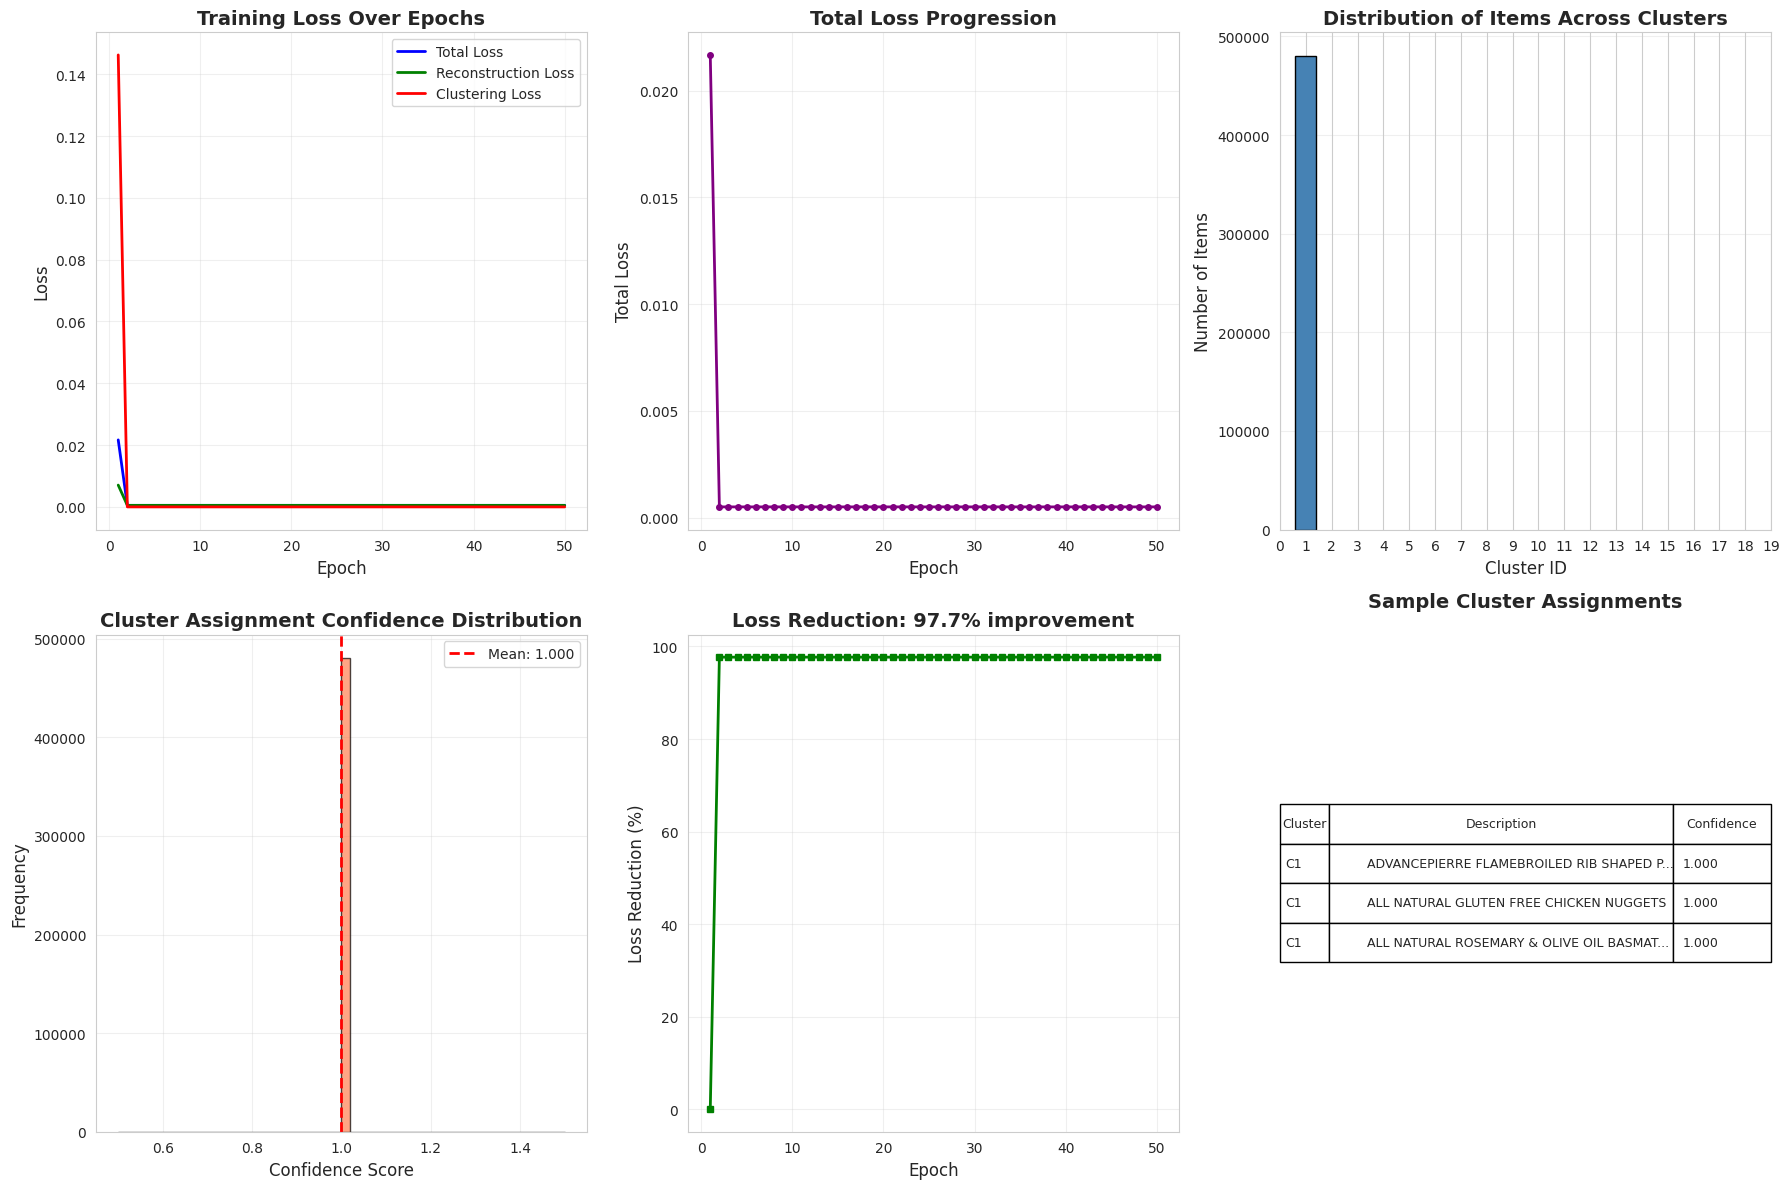

In [11]:
encoder.eval()
clustering_layer.eval()

with torch.no_grad():
    encoded = encoder(X_tensor)
    cluster_logits = clustering_layer(encoded)
    cluster_assignments = torch.argmax(cluster_logits, dim=1).numpy()
    cluster_probabilities = torch.softmax(cluster_logits, dim=1).numpy()

# Add to dataframe
df['cluster'] = cluster_assignments
df['cluster_confidence'] = cluster_probabilities.max(axis=1)

print(f"\nCluster distribution:")
print(df['cluster'].value_counts().sort_index())

# ==== VISUALIZATION ====
print("\n=== Creating Visualizations ===")

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Create figure with subplots
fig = plt.figure(figsize=(18, 12))

# 1. Loss curves over epochs
ax1 = plt.subplot(2, 3, 1)
plt.plot(history['epoch'], history['total_loss'], label='Total Loss', linewidth=2, color='blue')
plt.plot(history['epoch'], history['reconstruction_loss'], label='Reconstruction Loss', linewidth=2, color='green')
plt.plot(history['epoch'], history['clustering_loss'], label='Clustering Loss', linewidth=2, color='red')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training Loss Over Epochs', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Total loss only (zoomed)
ax2 = plt.subplot(2, 3, 2)
plt.plot(history['epoch'], history['total_loss'], linewidth=2, color='purple', marker='o', markersize=4)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Total Loss', fontsize=12)
plt.title('Total Loss Progression', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# 3. Cluster distribution (bar chart)
ax3 = plt.subplot(2, 3, 3)
cluster_counts = df['cluster'].value_counts().sort_index()
plt.bar(cluster_counts.index, cluster_counts.values, color='steelblue', edgecolor='black')
plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Number of Items', fontsize=12)
plt.title('Distribution of Items Across Clusters', fontsize=14, fontweight='bold')
plt.xticks(range(n_clusters))
plt.grid(True, alpha=0.3, axis='y')

# 4. Cluster confidence distribution
ax4 = plt.subplot(2, 3, 4)
plt.hist(df['cluster_confidence'], bins=50, color='coral', edgecolor='black', alpha=0.7)
plt.xlabel('Confidence Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Cluster Assignment Confidence Distribution', fontsize=14, fontweight='bold')
plt.axvline(df['cluster_confidence'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["cluster_confidence"].mean():.3f}')
plt.legend()
plt.grid(True, alpha=0.3)

# 5. Loss reduction percentage
ax5 = plt.subplot(2, 3, 5)
initial_loss = history['total_loss'][0]
final_loss = history['total_loss'][-1]
loss_reduction = [(initial_loss - loss) / initial_loss * 100 for loss in history['total_loss']]
plt.plot(history['epoch'], loss_reduction, linewidth=2, color='green', marker='s', markersize=4)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss Reduction (%)', fontsize=12)
plt.title(f'Loss Reduction: {loss_reduction[-1]:.1f}% improvement', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# 6. Sample results table
ax6 = plt.subplot(2, 3, 6)
ax6.axis('tight')
ax6.axis('off')

# Show sample from each cluster (first 5 clusters)
sample_data = []
for cluster_id in range(min(5, n_clusters)):
    cluster_samples = df[df['cluster'] == cluster_id].head(3)
    for idx, row in cluster_samples.iterrows():
        sample_data.append([
            f"C{cluster_id}",
            row['description'][:40] + "..." if len(row['description']) > 40 else row['description'],
            f"{row['cluster_confidence']:.3f}"
        ])

table = ax6.table(cellText=sample_data,
                  colLabels=['Cluster', 'Description', 'Confidence'],
                  cellLoc='left',
                  loc='center',
                  colWidths=[0.1, 0.7, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)
ax6.set_title('Sample Cluster Assignments', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('clustering_results.png', dpi=300, bbox_inches='tight')
plt.show()


In [12]:

# ==== DETAILED CLUSTER ANALYSIS ====
print("\n=== Cluster Analysis ===")

for cluster_id in range(n_clusters):
    cluster_data = df[df['cluster'] == cluster_id]
    print(f"\n--- Cluster {cluster_id} ({len(cluster_data)} items) ---")
    print(f"Average confidence: {cluster_data['cluster_confidence'].mean():.3f}")
    print(f"Sample descriptions:")
    for idx, desc in enumerate(cluster_data['description'].head(5)):
        print(f"  {idx+1}. {desc}")

# ==== SUMMARY STATISTICS ====
print("\n=== Summary Statistics ===")
print(f"Total items clustered: {len(df)}")
print(f"Number of clusters: {n_clusters}")
print(f"Average cluster size: {len(df) / n_clusters:.1f}")
print(f"Average confidence: {df['cluster_confidence'].mean():.3f}")
print(f"Final total loss: {history['total_loss'][-1]:.4f}")
print(f"Loss reduction: {loss_reduction[-1]:.1f}%")

# Save results
df.to_csv('clustered_food_descriptions.csv', index=False)
print("\n✓ Results saved to 'clustered_food_descriptions.csv'")
print("✓ Visualization saved to 'clustering_results.png'")



=== Cluster Analysis ===

--- Cluster 0 (0 items) ---
Average confidence: nan
Sample descriptions:

--- Cluster 1 (480176 items) ---
Average confidence: 1.000
Sample descriptions:
  1.  ADVANCEPIERRE FLAMEBROILED RIB SHAPED PORK PATTY TOPPED WITH BBQ SAUCE 
  2.  ALL NATURAL GLUTEN FREE CHICKEN NUGGETS
  3.  ALL NATURAL ROSEMARY & OLIVE OIL BASMATI RICE, ROSEMARY; OLIVE OIL
  4.  ALMOND MILK
  5.  ALMOND MILK, ORIGINAL

--- Cluster 2 (0 items) ---
Average confidence: nan
Sample descriptions:

--- Cluster 3 (0 items) ---
Average confidence: nan
Sample descriptions:

--- Cluster 4 (0 items) ---
Average confidence: nan
Sample descriptions:

--- Cluster 5 (0 items) ---
Average confidence: nan
Sample descriptions:

--- Cluster 6 (0 items) ---
Average confidence: nan
Sample descriptions:

--- Cluster 7 (0 items) ---
Average confidence: nan
Sample descriptions:

--- Cluster 8 (0 items) ---
Average confidence: nan
Sample descriptions:

--- Cluster 9 (0 items) ---
Average confidence: nan
Sampl